In [9]:
pip install langchain langgraph langchain-groq pydantic 


Note: you may need to restart the kernel to use updated packages.


In [10]:

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import operator
from langchain_groq import ChatGroq
import os

In [12]:
class StateRes(TypedDict):
    a: int
    b: int
    c: int
    
    equation: str
    discriminant: float
    result: str

In [13]:
def show_equation(state: StateRes):
    equation= f'{state['a']}x2{state['b']}x{state['c']}'

    return {'equation': equation}

def calculate_discriminant(state: StateRes):
    discriminant = state['b']**2 - 4*(state['a'] * state['c'])    
    return {'discriminant': discriminant}

def real_roots(state: StateRes):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}

def repeated_roots(state: StateRes):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

def no_real_roots(state: StateRes):

    result = f'No real roots'

    return {'result': result}

def check_condition(state: StateRes) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

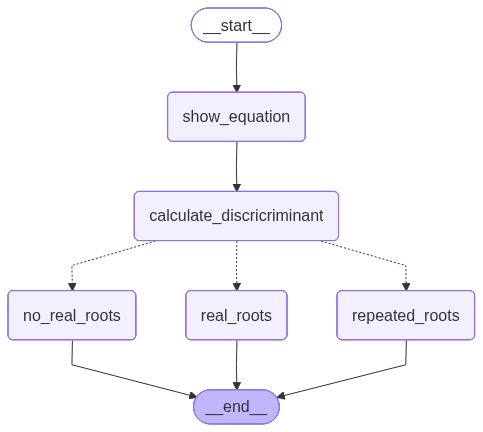

In [14]:
graph= StateGraph(StateRes)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discricriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation','calculate_discricriminant')

graph.add_conditional_edges('calculate_discricriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

workflow

In [15]:
intial={
    'a': 14,
    'b': -16,
    'c': -9
}

workflow.invoke(intial)

{'a': 14,
 'b': -16,
 'c': -9,
 'equation': '14x2-16x-9',
 'discriminant': 760,
 'result': 'The roots are 1.5560034822921587 and -0.41314633943501583'}